In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import torch
import numpy as np
from pathlib import Path
from datetime import datetime
from typing import Dict, List, Tuple, Optional
import os,sys
sys.path.append("/home/mnurisso/miller_npl/generalization_transformer_marc/src")
import networkx as nx
import matplotlib.pyplot as plt
import pickle 
# Import necessary modules and classes
from MillerDataGen import MillerDataGenerator, DataGeneratorConfig

from MillerTest import MillerTestConfig, create_model
from MillerTrainer import MillerTrainer, TrainerConfig
from scipy.signal import savgol_filter


In [3]:
N_INPUTS = 30 # Number of inputs
FEATURE_DIM = 10 # Number of latent dimensions
SEQUENCE_LEN = [3,4,5,6,7,8,9,10] # Number of items in the sim. test (includes probbe)
SAVE = False
NUM_SAMPLES = 2000
BATCH_SIZE = 128 
INIT_SCALE = 2 # Initialization scale
N_EPOCHS = 1000

# Circle
t = torch.linspace(0,1,N_INPUTS).unsqueeze(1)
xx = torch.cat((torch.cos(2*torch.pi*t),torch.sin(2*torch.pi*t)),1)
METRIC_MATRIX = torch.cdist(xx,xx)


___

In [4]:
histories = []
embeddings = []
for seq_len in SEQUENCE_LEN:
    print(f"Sequence len: {seq_len}")
    genconf = DataGeneratorConfig()
    genconf.num_inputs = N_INPUTS
    genconf.batch_size = BATCH_SIZE
    genconf.num_samples = NUM_SAMPLES
    genconf.sequence_len = seq_len
    genconf.metric_matrix = METRIC_MATRIX

    gen = MillerDataGenerator(config = genconf)

    model_config = MillerTestConfig(
                feature_dim=FEATURE_DIM,
                input_dim=genconf.num_inputs,
                sequence_len=genconf.sequence_len,
                init_scale = INIT_SCALE
            )

    tconf = TrainerConfig()
    tconf.losses = ["reconstruction","similarity"]
    tconf.num_inputs = genconf.num_inputs
    tconf.batch_size = BATCH_SIZE
    tconf.num_epochs: int = N_EPOCHS
    tconf.learning_rate: float = 7*1e-3
    tconf.weight_decay: float = 0
    tconf.patience = 400
    tconf.min_lr = 0
    tconf.lambda_rec = 0
    tconf.lambda_sim = .1

    model = create_model(model_config)
    torch.nn.init.uniform_(model.embed.weight, a = 0*model_config.init_scale,b = model_config.init_scale)

    trainer = MillerTrainer(model, gen, tconf)
    history,embs = trainer.train(shutupfor = 500,compute_embeddings=True)
    histories.append(history)
    embeddings.append(embs)


Sequence len: 3
Epoch 0:
  Train - Sim Loss: 0.0704, Reconstruction Loss: 0.0000
  Val - G Score: 0.5012, I Score: 0.5643
Epoch 500:
  Train - Sim Loss: 0.0396, Reconstruction Loss: 0.0000
  Val - G Score: 0.7239, I Score: 0.9088
Sequence len: 4
Epoch 0:
  Train - Sim Loss: 0.1109, Reconstruction Loss: 0.0000
  Val - G Score: 0.3372, I Score: 0.3932
Epoch 500:
  Train - Sim Loss: 0.0522, Reconstruction Loss: 0.0000
  Val - G Score: 0.6831, I Score: 0.8512
Sequence len: 5
Epoch 0:
  Train - Sim Loss: 0.1403, Reconstruction Loss: 0.0000
  Val - G Score: 0.2515, I Score: 0.3002
Epoch 500:
  Train - Sim Loss: 0.0580, Reconstruction Loss: 0.0000
  Val - G Score: 0.6689, I Score: 0.8060
Sequence len: 6
Epoch 0:
  Train - Sim Loss: 0.1619, Reconstruction Loss: 0.0000
  Val - G Score: 0.2041, I Score: 0.2454
Epoch 500:
  Train - Sim Loss: 0.0577, Reconstruction Loss: 0.0000
  Val - G Score: 0.6786, I Score: 0.7478
Sequence len: 7
Epoch 0:
  Train - Sim Loss: 0.1794, Reconstruction Loss: 0.0000

In [10]:
save_dict = {"gen_config":genconf, "train_config":tconf, "model_config":model_config, "training_histories":histories, "embeddings":embeddings, "sequence_len":SEQUENCE_LEN}
with open('/home/mnurisso/miller_npl/generalization_transformer_marc/results/sequence_len_run_circle.pickle', 'wb') as handle:
    pickle.dump(save_dict, handle, protocol=pickle.HIGHEST_PROTOCOL)


In [4]:
save_dict = pickle.load(open("/home/mnurisso/miller_npl/generalization_transformer_marc/results/sequence_len_run_circle.pickle",'rb'))
genconf = save_dict['gen_config']
tconf = save_dict['train_config']
histories = save_dict['training_histories']
embeddings = save_dict['embeddings']
SEQUENCE_LEN = save_dict['sequence_len']
model_config = save_dict['model_config']

___

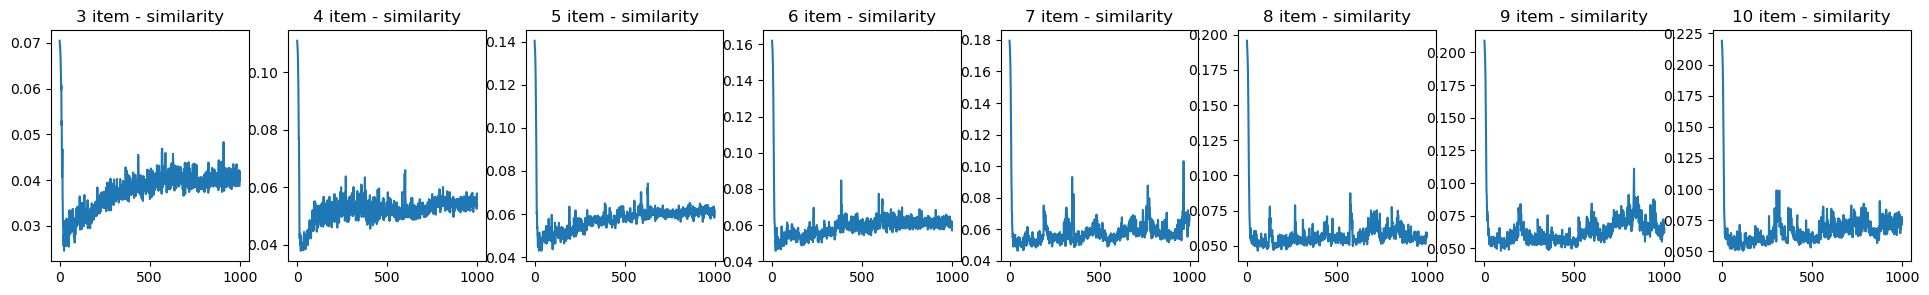

In [8]:
f,axs=plt.subplots(1,len(SEQUENCE_LEN), figsize = (3*len(SEQUENCE_LEN),3))
for i,l in enumerate(SEQUENCE_LEN):
    axs[i].plot(histories[i]["similarity_losses"])
    axs[i].set_title(f"{l} item - similarity")

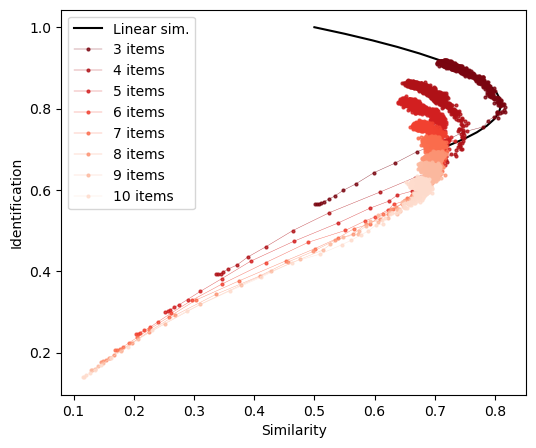

In [13]:
tspace = np.linspace(0,1,20)
f = plt.figure(figsize = (6,5))

plt.plot(1/2 + tspace - (3/2 - np.log(2))*tspace**2, 1 - (1-np.log(2))*tspace,color = "k", label = "Linear sim.")
#plt.plot(1/2 + tspace - tspace**2, 1 - tspace/2,color = "grey", alpha = 0.5, linestyle = "--", label = "Constant sim.")
for i,history in enumerate(histories):
        plt.plot(history['similarity_scores'],
                history['identification_scores'], 
                '-o', markersize = 2, linewidth = 0.3, alpha = 0.8, color = plt.cm.Reds_r(30*i+10),
                label = f"{SEQUENCE_LEN[i]} items")

#plt.scatter([histories[0]['similarity_scores'][0]],[histories[0]['identification_scores'][0]],color = "k", s = 100, zorder = 30, marker = "x")

#plt.xlim([0.48,1.02])
#plt.ylim([0.48,1.02])
plt.xlabel("Similarity")
plt.ylabel("Identification")
plt.legend()

In [ ]:
sim_vals = []
id_vals = []
SEQUENCE_LEN2 = SEQUENCE_LEN +  list(range(11,30))
for trained_on_id in range(len(SEQUENCE_LEN)):
    max_gen_id = np.argmax(histories[trained_on_id]['similarity_scores'])
    model = create_model(model_config)
    model.embed.weight.data = torch.tensor(embeddings[trained_on_id][max_gen_id]).T

    sim_vals.append([])
    id_vals.append([])
    for i,l in enumerate(SEQUENCE_LEN2):
        genconf.sequence_len = l
        genconf.batch_size = 40
        gen = MillerDataGenerator(config = genconf)
        trainer = MillerTrainer(model, gen, tconf)
        val = trainer.validate()
        sim_vals[-1].append(val['generalization_score'])
        id_vals[-1].append(val['identification_score'])


Text(0, 0.5, 'Identification')

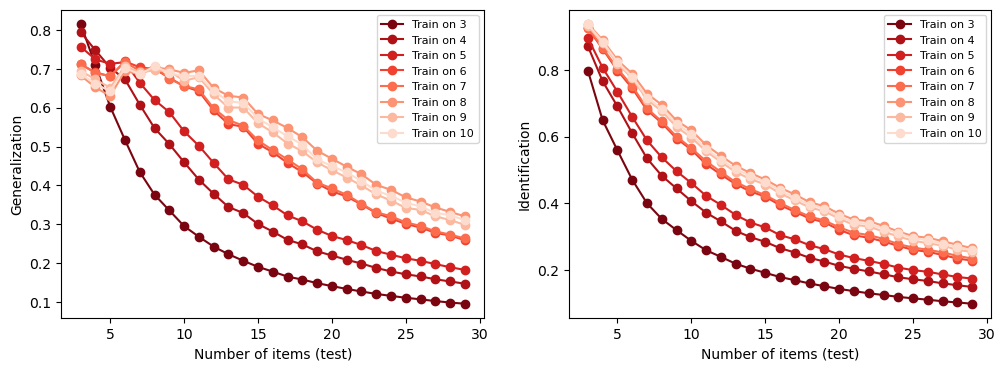

In [14]:

f,axs = plt.subplots(1,2,figsize = (12,4))
for trained_on_id in range(len(SEQUENCE_LEN)):
    axs[0].plot(SEQUENCE_LEN2,sim_vals[trained_on_id], '-o',color = plt.cm.Reds_r(30*trained_on_id+10), label = f"Train on {SEQUENCE_LEN[trained_on_id]}")
axs[0].legend(fontsize=8)
axs[0].set_xlabel("Number of items (test)")
axs[0].set_ylabel("Generalization")

for trained_on_id in range(len(SEQUENCE_LEN)):
    axs[1].plot(SEQUENCE_LEN2,id_vals[trained_on_id], '-o',color = plt.cm.Reds_r(30*trained_on_id+10), label = f"Train on {SEQUENCE_LEN[trained_on_id]}")
axs[1].legend(fontsize=8)
axs[1].set_xlabel("Number of items (test)")
axs[1].set_ylabel("Identification")

In [ ]:
sim_vals_simulate = []
id_vals_simulate = []

for k,l in enumerate(SEQUENCE_LEN):
    print(l)
    genconf_2 = genconf
    genconf_2.sequence_len = l
    genconf_2.batch_size= 1024
    genconf_2.num_inputs = 40



    t = torch.linspace(0,1,genconf_2.num_inputs).unsqueeze(1)
    d = torch.zeros(len(t),len(t))
    for i in range(len(t)):
        for j in range(len(t)):
            m = np.abs(t[i]-t[j])
            d[i,j] = min(m,1-m)

    genconf_2.metric_matrix = d

    gen_2 = MillerDataGenerator(config = genconf)
    sim_vals_simulate.append([])
    id_vals_simulate.append([])
    for eps in np.linspace(0.001,torch.max(genconf_2.metric_matrix),40):
        b = gen.generate_similarity_test_batch()

        dists = genconf_2.metric_matrix[b[0][:,:-1].T,b[0][:,-1]]
        sim_num = torch.maximum(1 - torch.diag(dists[b[1],:])/eps,torch.tensor(0)) + 10**-10
        sim_den = torch.sum(torch.maximum(1 - dists/eps,torch.tensor(0)) + 10**-10,0)
        prob = sim_num/sim_den
        sim_vals_simulate[-1].append(torch.mean(prob).numpy())

        b = gen.generate_identification_test_batch()
        dists = genconf_2.metric_matrix[b[0][:,:-1].T,b[0][:,-1]]
        sim_num = torch.maximum(1 - torch.diag(dists[b[1],:])/eps,torch.tensor(0)) + 10**-10
        sim_den = torch.sum(torch.maximum(1 - dists/eps,torch.tensor(0)) + 10**-10,0)
        prob = sim_num/sim_den
        id_vals_simulate[-1].append(torch.mean(prob).numpy())

    plt.plot(sim_vals_simulate[-1], id_vals_simulate[-1])

    #tspace = np.linspace(0,1,20)
    #plt.plot(1/2 + tspace - (3/2 - np.log(2))*tspace**2, 1 - (1-np.log(2))*tspace,color = "k", label = "Linear sim.")


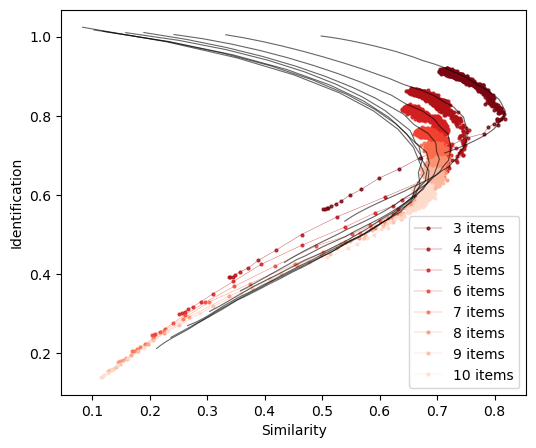

In [76]:
tspace = np.linspace(0,1,20)
f = plt.figure(figsize = (6,5))

#plt.plot(1/2 + tspace - (3/2 - np.log(2))*tspace**2, 1 - (1-np.log(2))*tspace,color = "k", label = "Linear sim.")
#plt.plot(1/2 + tspace - tspace**2, 1 - tspace/2,color = "grey", alpha = 0.5, linestyle = "--", label = "Constant sim.")
for i,history in enumerate(histories):

        plt.plot(history['similarity_scores'],
                history['identification_scores'], 
                '-o', markersize = 2, linewidth = 0.3, alpha = 0.8, color = plt.cm.Reds_r(30*i+10),
                label = f"{SEQUENCE_LEN[i]} items")

for i in range(len(SEQUENCE_LEN)):
    plt.plot(savgol_filter(sim_vals_simulate[i],16,3), savgol_filter(id_vals_simulate[i],16,3),'k',linewidth=0.8, alpha = 0.6)

#plt.scatter([histories[0]['similarity_scores'][0]],[histories[0]['identification_scores'][0]],color = "k", s = 100, zorder = 30, marker = "x")

#plt.xlim([0.48,1.02])
#plt.ylim([0.48,1.02])
plt.xlabel("Similarity")
plt.ylabel("Identification")
plt.legend()

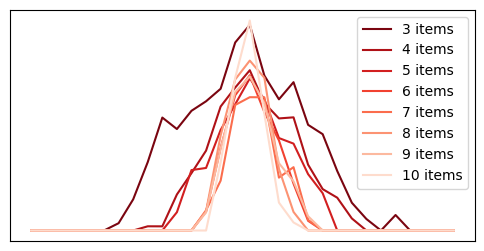

In [123]:
xx = np.linspace(0,1,N_INPUTS)
ids = [15]

f= plt.figure(figsize = (6,3))
for i,l in enumerate(SEQUENCE_LEN):
    max_gen_id = np.argmax(histories[i]['similarity_scores'])
    S = np.maximum(0,embeddings[i][max_gen_id]@embeddings[i][max_gen_id].T)
    for j in ids:
        plt.plot(xx,S[j,:], color = plt.cm.Reds_r(i*30+10), label = f"{l} items")
        #plt.fill_between(xx,0,S[j,:], alpha = 0.1)
plt.xticks([])
plt.yticks([])
plt.legend()